In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import os

# Setup stile e cartelle
sns.set_theme(style="white")
plt.rcParams['figure.figsize'] = [10, 6]  # Mantiene i grafici grandi uguali
os.makedirs('output/grafici', exist_ok=True)

# Caricamento dataset pulito
file_path = os.path.join('output', 'dati_puliti', 'cleaned_retail.csv')
df = pd.read_csv(file_path)
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

print("Dataset caricato con successo!")
print(f"Righe totali: {df.shape[0]} | Colonne: {df.shape[1]}")
df.head()

Dataset caricato con successo!
Righe totali: 876436 | Colonne: 10


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,is_anonymous,TotalPrice
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,False,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,False,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,False,81.0
3,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,False,30.0
4,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085.0,United Kingdom,False,39.6


In [10]:
#[FASE 3 — Task 1] Calcolo dei KPI di Business e Distribuzione Scontrini

# 1. Calcolo il fatturato totale complessivo
fatturato_totale = df['TotalPrice'].sum()

# 2. Conto il numero unico di scontrini (Invoice) e di clienti (Customer ID)
num_scontrini = df['Invoice'].nunique()
num_clienti = df['Customer ID'].nunique()

print(f"1. Fatturato Totale Complessivo: {fatturato_totale:,.2f} £")
print(f"2. Numero Unico di Scontrini: {num_scontrini}")
print(f"3. Numero Unico di Clienti: {num_clienti}")

1. Fatturato Totale Complessivo: 10,405,563.73 £
2. Numero Unico di Scontrini: 36374
3. Numero Unico di Clienti: 5682


In [11]:
# 3. Calcolo lo scontrino medio (AOV - Average Order Value)
aov = fatturato_totale / num_scontrini

print(f"3. Scontrino Medio (AOV): {aov:.2f} £")

3. Scontrino Medio (AOV): 286.07 £


In [12]:
# 4. Raggruppo i dati per Invoice e calcolo il valore totale di ogni scontrino
scontrini_valore = df.groupby('Invoice')['TotalPrice'].sum().reset_index()

print("Raggruppamento completato con successo!")
print(scontrini_valore.head())

Raggruppamento completato con successo!
   Invoice  TotalPrice
0   489434      404.50
1   489435      145.80
2   489436      613.33
3   489437      282.90
4   489438       27.44


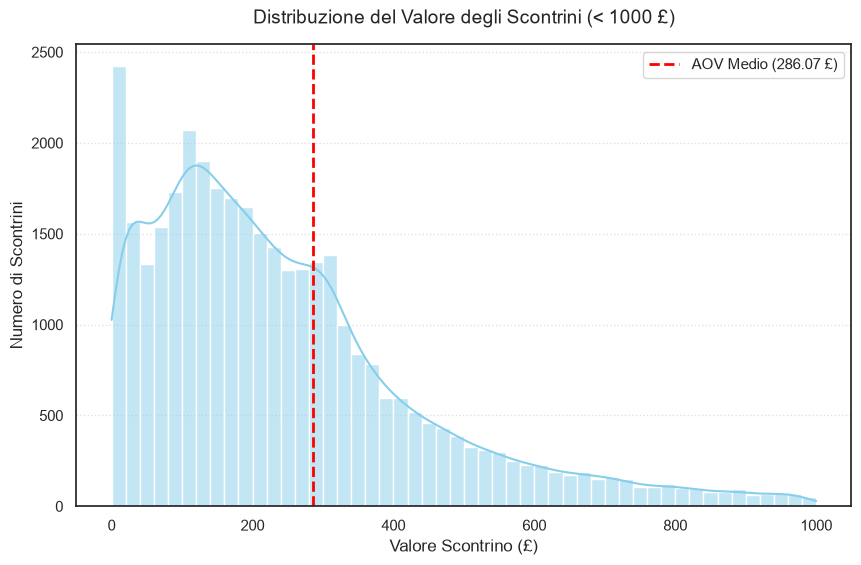

Grafico creato e salvato con successo in: output\grafici\distribuzione_scontrini.png


In [13]:
# 5. Grafico della distribuzione del valore degli scontrini (filtrato sotto i 1000€ per leggibilità)
scontrini_filtrati = scontrini_valore[scontrini_valore['TotalPrice'] < 1000]

plt.figure()
sns.histplot(data=scontrini_filtrati, x='TotalPrice', bins=50, kde=True, color='skyblue')

# Aggiungo una linea per indicare lo scontrino medio (AOV) calcolato prima
plt.axvline(aov, color='red', linestyle='--', linewidth=2, label=f'AOV Medio ({aov:.2f} £)')

plt.title('Distribuzione del Valore degli Scontrini (< 1000 £)', fontsize=14, pad=15)
plt.xlabel('Valore Scontrino (£)', fontsize=12)
plt.ylabel('Numero di Scontrini', fontsize=12)
plt.legend()
plt.grid(axis='y', linestyle=':', alpha=0.6)

# Salvataggio del grafico nella cartella corretta
output_plot_path = os.path.join('output', 'grafici', 'distribuzione_scontrini.png')
plt.savefig(output_plot_path, bbox_inches='tight', dpi=300)
plt.show()

print(f"Grafico creato e salvato con successo in: {output_plot_path}")